## Modelo Base (Baseline) de Machine Learning

### By: Maricel Martinez

### Date: 2026-08-28

### Description:

Creación del modelo base (Issue 5) del proyecto `Precios-casas-Boston`. El objetivo es tener una referencia de desempeño contra la cual comparar los modelos de machine learning que se entrenen después: si un modelo complejo no supera claramente a este baseline, no justifica su costo de desarrollo, cómputo ni mantenimiento.

Como el problema es de **regresión** (predecir `medv`, el valor mediano de la vivienda en miles de USD), el diseño y las métricas se adaptan respecto al ejemplo de clasificación del profesor (Titanic): se usan MAE, RMSE, R² y MAPE en lugar de accuracy / precision / recall.

Se construyen **dos niveles de referencia**:

1. **Modelo dummy** ([`DummyRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html)): predice siempre una constante (media o mediana de `medv`) ignorando por completo las variables predictoras. Es el piso absoluto: por construcción su R² es ≈ 0 y cualquier modelo útil debe superarlo.
2. **Modelo heurístico**: reglas de negocio simples sobre `rm` (habitaciones promedio) y `lstat` (% de población de estrato bajo), las dos variables con mayor relación con `medv` según los EDA previos. Mide cuánto se puede lograr con solo conocimiento del dominio, sin aprendizaje automático.

### Alcance

1. Reutilización del pipeline de procesamiento construido en el notebook `06.feature_engineering` (Issue 4)
2. División Train / Test
3. Evaluación con varias métricas de regresión
4. Validación cruzada (media y desviación estándar de cada métrica)
5. Selección y justificación de la variable más importante
6. Curva de aprendizaje (Learning curve)
7. Gráficas de escalabilidad (tiempo de entrenamiento, tiempo de predicción y score)
8. Interpretación, análisis de resultados, conclusiones, recomendaciones y propuestas

### Nota de flujo de trabajo

Este notebook se desarrolla en una rama nueva siguiendo Gitflow (`feature/05-baseline-model`) y su incorporación a `main` requiere Pull Request con al menos una revisión de otra persona del curso y el paso de los checks de CI/CD, según lo establece la Issue 5. Los comandos usados están al final del notebook.

## 📚 Import libraries

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from IPython.display import Markdown, display
from sklearn import set_config
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    OneHotEncoder,
    StandardScaler,
)

# Configuración y versiones

In [2]:
pd.set_option("display.float_format", "{:.2f}".format)

# los transformadores devuelven DataFrame en lugar de ndarray: conserva los
# nombres de columna a lo largo del pipeline y facilita revisar el resultado
set_config(transform_output="pandas")

# semilla y parámetros fijos para que todo el notebook sea reproducible
# (el ejemplo del profesor no fijaba random_state en el train_test_split,
#  por lo que sus resultados cambiaban en cada ejecución)
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 10

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("sklearn version:", sk.__version__)
print("joblib version:", joblib.__version__)

Pandas version: 3.0.5
Numpy version: 2.5.2
sklearn version: 1.9.0
joblib version: 1.5.3


## 💾 Load data

In [3]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
MODELS_DIR = DATA_DIR / "06_models"
MODEL_OUTPUT_DIR = DATA_DIR / "07_model_output"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet", engine="pyarrow"
)
print("Datos originales:", boston_df.shape)

Datos originales: (343, 14)


# 👷 Preparación de datos

Se reproducen exactamente los pasos de limpieza y de creación de atributos definidos en el notebook `06.feature_engineering`, ya que el modelo base debe evaluarse sobre los mismos datos que usarán los modelos de machine learning posteriores:

1. Eliminar filas duplicadas (10 filas)
2. Eliminar filas sin variable objetivo `medv` (12 filas); la variable objetivo no se imputa
3. Marcar con `medv_censored` las observaciones con `medv = 50.00` (posible censura) **sin eliminarlas**, para conservar la comparabilidad con el notebook anterior y poder medir aparte su aporte al error
4. Descartar `tax` por su colinealidad con `rad` (correlación 0.91)
5. Crear el atributo `rad_group` (`alto` para `rad = 24`, `bajo` para el resto)

In [4]:
MEDV_CENSORED_VALUE = 50.0
RAD_HIGH_VALUE = 24

selected_features = [
    "crim",
    "zn",
    "indus",
    "chas",
    "nox",
    "rm",
    "age",
    "dis",
    "rad",
    "tax",
    "ptratio",
    "black",
    "lstat",
    "medv",
]

boston_features = boston_df[selected_features].copy()

# 1. filas duplicadas
duplicated_rows = boston_features.duplicated().sum()
boston_features = boston_features.drop_duplicates()

# 2. filas sin variable objetivo
missing_target = boston_features["medv"].isna().sum()
boston_features = boston_features.dropna(subset=["medv"])

# 3. marcar posible censura en medv (no se eliminan las filas)
boston_features["medv_censored"] = (
    boston_features["medv"] == MEDV_CENSORED_VALUE
).astype(int)

# 4. feature selection: se descarta tax por colinealidad con rad
boston_features = boston_features.drop(columns=["tax"])

# 5. nuevo atributo rad_group
boston_features["rad_group"] = np.where(
    boston_features["rad"] == RAD_HIGH_VALUE, "alto", "bajo"
)

print("Filas duplicadas eliminadas:", duplicated_rows)
print("Filas sin medv eliminadas:", missing_target)
print("Dataset preparado:", boston_features.shape)
print("Observaciones censuradas (medv = 50):", boston_features["medv_censored"].sum())

Filas duplicadas eliminadas: 10
Filas sin medv eliminadas: 12
Dataset preparado: (321, 15)
Observaciones censuradas (medv = 50): 11


In [5]:
boston_features.info()

<class 'pandas.DataFrame'>
Index: 321 entries, 0 to 332
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   crim           319 non-null    float64
 1   zn             321 non-null    float64
 2   indus          317 non-null    float64
 3   chas           321 non-null    float64
 4   nox            319 non-null    float64
 5   rm             319 non-null    float64
 6   age            320 non-null    float64
 7   dis            319 non-null    float64
 8   rad            320 non-null    float64
 9   ptratio        320 non-null    float64
 10  black          319 non-null    float64
 11  lstat          321 non-null    float64
 12  medv           321 non-null    float64
 13  medv_censored  321 non-null    int64  
 14  rad_group      321 non-null    str    
dtypes: float64(13), int64(1), str(1)
memory usage: 41.4 KB


#### Interpretación

El dataset queda en **321 filas y 15 columnas** (14 predictoras + la variable objetivo `medv`), igual que al cerrar el notebook `06.feature_engineering`. Reproducir aquí estos pasos con código y no con un archivo intermedio guardado mantiene el notebook autocontenido, aunque lo ideal —y así se recomienda al final— es mover esta lógica a un módulo de `src/` para no duplicarla en cada notebook.

### Distribución de la variable objetivo

Antes de definir el modelo base conviene revisar la distribución de `medv`, porque el desempeño del modelo dummy queda determinado por ella: predecir siempre la media produce un RMSE igual a la desviación estándar de `medv`.

count   321.00
mean     22.76
std       9.23
min       5.00
25%      17.40
50%      21.60
75%      25.00
max      50.00
Name: medv, dtype: float64

Asimetría (skewness): 1.1336


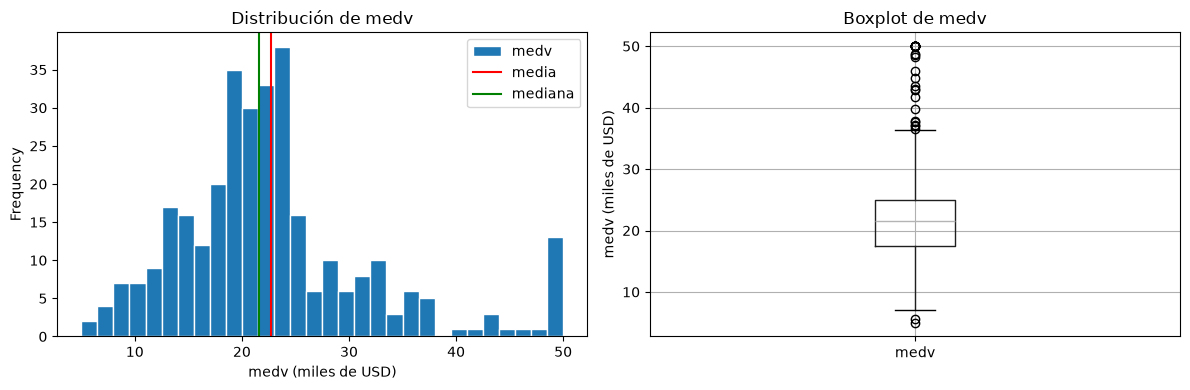

In [6]:
target_stats = boston_features["medv"].describe()
print(target_stats)
print("\nAsimetría (skewness):", round(boston_features["medv"].skew(), 4))

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
boston_features["medv"].plot.hist(bins=30, ax=ax[0], edgecolor="white")
ax[0].axvline(boston_features["medv"].mean(), color="red", label="media")
ax[0].axvline(boston_features["medv"].median(), color="green", label="mediana")
ax[0].set_title("Distribución de medv")
ax[0].set_xlabel("medv (miles de USD)")
ax[0].legend()

boston_features.boxplot(column="medv", ax=ax[1])
ax[1].set_title("Boxplot de medv")
ax[1].set_ylabel("medv (miles de USD)")
plt.tight_layout()
plt.show()

#### Interpretación

La distribución de `medv` es asimétrica a la derecha y con una acumulación visible en el valor 50 (las 11 observaciones marcadas como censuradas). Esto tiene dos consecuencias para el modelo base:

- La **media y la mediana no coinciden**, por lo que vale la pena evaluar `DummyRegressor` con ambas estrategias: la mediana suele dar mejor MAE y la media mejor RMSE.
- El RMSE del dummy será aproximadamente la desviación estándar de `medv`, y ese número es la referencia práctica a superar por cualquier modelo posterior.

# ⚙️ Pipeline de procesamiento de datos (reutilizado del notebook 06)

Se reutiliza el pipeline de scikit-learn construido en la tarea anterior, con dos ajustes menores de robustez: `OneHotEncoder(sparse_output=False)` para que la salida sea siempre un `DataFrame` denso (necesario al usar `set_config(transform_output="pandas")`), y los mismos grupos de columnas y transformaciones documentados en el notebook 06.

In [7]:
cols_log = ["crim"]

cols_numeric = ["zn", "indus", "nox", "rm", "age", "dis", "ptratio", "black", "lstat"]

cols_discretize = ["age"]

cols_binary = ["chas", "medv_censored"]

cols_nominal = ["rad", "rad_group"]

In [8]:
# Pipeline: variable con transformación logarítmica antes de escalar
log_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline: variables numéricas continuas
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline: discretización de age en 4 categorías (nuevo atributo)
discretize_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "discretizer",
            KBinsDiscretizer(n_bins=4, encode="ordinal", strategy="quantile"),
        ),
    ]
)

# Pipeline: variables binarias (ya en 0/1, solo se imputan por seguridad)
binary_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ]
)

# Pipeline: variables categóricas nominales
nominal_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("log", log_pipe, cols_log),
        ("numeric", numeric_pipe, cols_numeric),
        ("discretize", discretize_pipe, cols_discretize),
        ("binary", binary_pipe, cols_binary),
        ("nominal", nominal_pipe, cols_nominal),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

### Pipeline reducido para el modelo heurístico

El modelo heurístico razona con **reglas en las unidades originales** de las variables (`rm` en número de habitaciones, `lstat` en porcentaje), por lo que no puede recibir las columnas estandarizadas: un umbral como `lstat < 10` no tiene sentido sobre valores centrados en 0.

Por eso se define un segundo `ColumnTransformer` que solo imputa (mediana) y deja pasar `rm` y `lstat` sin escalar. Es el mismo criterio del ejemplo del profesor, que también usó un preprocesador reducido (`passthrough` + imputación) para su modelo heurístico. El pipeline completo se usa con el modelo dummy y quedará listo para los modelos de machine learning de la siguiente tarea.

In [10]:
cols_heuristic = ["rm", "lstat"]

heuristic_preprocessor = ColumnTransformer(
    transformers=[
        ("raw", SimpleImputer(strategy="median"), cols_heuristic),
    ]
)
heuristic_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('raw', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fe

# ✂️ Train / Test split

Se usa la misma división que en el notebook 06: 80 % entrenamiento y 20 % prueba, estratificada por `chas` (variable binaria con un grupo muy pequeño, que sin estratificar puede quedar subrepresentado) y con `random_state` fijo para que la partición sea idéntica y los resultados reproducibles.

In [11]:
X_features = boston_features.drop(columns=["medv"])
y_target = boston_features["medv"]

x_train, x_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=TEST_SIZE,
    stratify=X_features["chas"],
    random_state=RANDOM_STATE,
)

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train: (256, 14) (256,)
Test : (65, 14) (65,)


In [12]:
# verificación de que no hay fuga de datos entre los dos conjuntos
shared_rows = set(x_train.index) & set(x_test.index)
print("Filas compartidas entre train y test:", len(shared_rows))

print(
    "Censurados en train:",
    int(x_train["medv_censored"].sum()),
    "| en test:",
    int(x_test["medv_censored"].sum()),
)
print("Media de medv en train:", round(y_train.mean(), 4))
print("Media de medv en test :", round(y_test.mean(), 4))

Filas compartidas entre train y test: 0
Censurados en train: 11 | en test: 0
Media de medv en train: 23.0496
Media de medv en test : 21.6323


#### Interpretación

El conjunto de entrenamiento queda con **256 filas** y el de prueba con **65**, sin filas compartidas entre ellos. Las medias de `medv` son parecidas (**23.05** en train y **21.63** en test), así que la partición no quedó sesgada hacia viviendas caras o baratas.

Hay un detalle importante que solo se ve al ejecutar: la división se estratificó por `chas` pero no por la censura, y **las 11 observaciones con `medv = 50` quedaron todas en el conjunto de entrenamiento (0 en prueba)**. Esto tiene dos consecuencias que se retoman más adelante: el conjunto de prueba resulta menos disperso que el de entrenamiento (desviación estándar de `medv` ≈ **6.7** frente a ≈ **9.7**), y el efecto de las viviendas censuradas sobre el error solo puede analizarse dentro del entrenamiento y la validación cruzada, no en la evaluación final.

# 🔍 Verificación del pipeline

In [13]:
x_train_transformed = preprocessor.fit_transform(x_train)

print("Dimensiones tras el preprocesamiento:", x_train_transformed.shape)
print("Valores nulos:", int(x_train_transformed.isna().sum().sum()))
x_train_transformed.head()

Dimensiones tras el preprocesamiento: (256, 24)
Valores nulos: 0


,log__crim,numeric__zn,numeric__indus,numeric__nox,numeric__rm,numeric__age,numeric__dis,numeric__ptratio,numeric__black,numeric__lstat,...,nominal__rad_2.0,nominal__rad_3.0,nominal__rad_4.0,nominal__rad_5.0,nominal__rad_6.0,nominal__rad_7.0,nominal__rad_8.0,nominal__rad_24.0,nominal__rad_group_alto,nominal__rad_group_bajo
233,-0.74,2.22,-1.33,-1.31,-0.53,-1.78,3.56,-0.09,0.37,-0.66,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
118,-0.68,-0.46,-0.99,-0.40,-0.96,0.74,-0.57,-0.90,0.43,0.30,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
122,-0.74,-0.46,-0.99,-0.40,-0.35,-0.75,-0.08,-0.90,0.38,-0.34,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
18,-0.06,-0.46,-0.40,-0.14,-0.77,0.94,0.27,1.20,-0.00,1.39,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
21,-0.65,-0.46,-0.71,-0.50,-0.42,-1.36,0.07,0.34,0.39,-0.33,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00


#### Interpretación

El pipeline entrega **256 filas y 24 columnas** sin valores nulos, consistente con el diseño del notebook 06 (1 columna de `crim` transformada con log, 9 numéricas escaladas, 1 `age` discretizada, 2 binarias y 11 columnas de One-Hot de `rad` y `rad_group`). El `preprocessor` se ajusta únicamente con `x_train`; dentro de la validación cruzada este ajuste se repite en cada fold automáticamente, que es la razón principal para trabajar con pipelines y no transformar los datos por fuera.

# 🎯 Selección de la variable más importante

La Issue 5 pide seleccionar la variable más importante y justificar la elección. Para no depender de un solo criterio se calculan cuatro medidas **usando únicamente el conjunto de entrenamiento** (mirar el conjunto de prueba para elegir variables sería fuga de información):

- **Correlación de Pearson**: fuerza de la relación lineal con `medv`.
- **Correlación de Spearman**: relación monótona, no necesariamente lineal; es más robusta a valores atípicos como los censurados en `medv = 50`.
- **Información mutua** (`mutual_info_regression`): captura dependencias no lineales que las correlaciones no ven.
- **R² univariado**: qué porcentaje de la varianza de `medv` explica una regresión lineal simple con esa única variable. Es el criterio más directo para un modelo base, porque responde justamente a "¿cuánto puedo predecir con una sola variable?".

Se evalúan solo las variables continuas: `chas` y `rad`/`rad_group` son categóricas y su aporte ya se analizó en los EDA previos (`rad = 24` es el grupo que concentra los precios más bajos).

In [14]:
numeric_candidates = [
    "crim",
    "zn",
    "indus",
    "nox",
    "rm",
    "age",
    "dis",
    "ptratio",
    "black",
    "lstat",
]

# imputación con la mediana del train solo para poder calcular las medidas
train_candidates = x_train[numeric_candidates].astype(float)
train_candidates = train_candidates.fillna(train_candidates.median())

pearson = train_candidates.corrwith(y_train, method="pearson")
spearman = train_candidates.corrwith(y_train, method="spearman")

mutual_info = pd.Series(
    mutual_info_regression(train_candidates, y_train, random_state=RANDOM_STATE),
    index=numeric_candidates,
)

univariate_r2 = {}
for column in numeric_candidates:
    single_var_model = LinearRegression().fit(train_candidates[[column]], y_train)
    univariate_r2[column] = single_var_model.score(train_candidates[[column]], y_train)

importance_df = pd.DataFrame(
    {
        "pearson": pearson,
        "abs_pearson": pearson.abs(),
        "abs_spearman": spearman.abs(),
        "mutual_info": mutual_info,
        "r2_univariado": pd.Series(univariate_r2),
    }
).sort_values("r2_univariado", ascending=False)

importance_df

,pearson,abs_pearson,abs_spearman,mutual_info,r2_univariado
lstat,-0.75,0.75,0.87,0.72,0.56
rm,0.69,0.69,0.63,0.54,0.48
ptratio,-0.52,0.52,0.56,0.37,0.27
crim,-0.44,0.44,0.53,0.31,0.19
indus,-0.44,0.44,0.54,0.41,0.19
nox,-0.40,0.40,0.54,0.41,0.16
zn,0.33,0.33,0.40,0.14,0.11
age,-0.33,0.33,0.53,0.35,0.11
black,0.33,0.33,0.12,0.13,0.11
dis,0.21,0.21,0.40,0.35,0.04


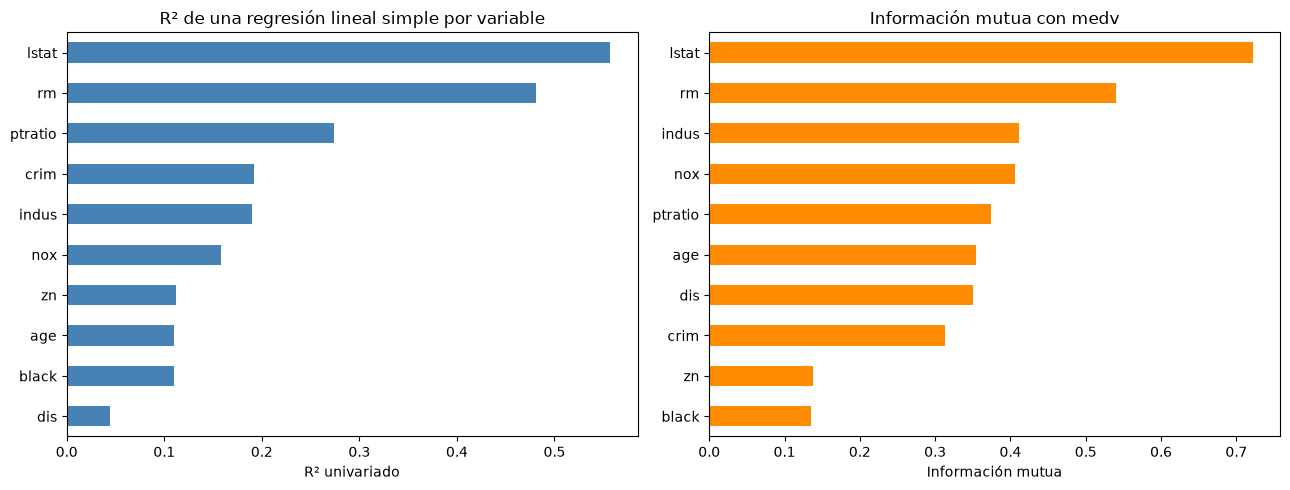

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

importance_df["r2_univariado"].sort_values().plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("R² de una regresión lineal simple por variable")
ax[0].set_xlabel("R² univariado")

importance_df["mutual_info"].sort_values().plot.barh(ax=ax[1], color="darkorange")
ax[1].set_title("Información mutua con medv")
ax[1].set_xlabel("Información mutua")

plt.tight_layout()
plt.show()

In [16]:
best_feature = importance_df.index[0]
runner_up_feature = importance_df.index[1]

display(
    Markdown(
        f"""
**Ranking obtenido:** la variable más importante es **`{best_feature}`**
(R² univariado = {importance_df.loc[best_feature, "r2_univariado"]:.4f},
Pearson = {importance_df.loc[best_feature, "pearson"]:.4f},
información mutua = {importance_df.loc[best_feature, "mutual_info"]:.4f}),
seguida por **`{runner_up_feature}`**
(R² univariado = {importance_df.loc[runner_up_feature, "r2_univariado"]:.4f},
Pearson = {importance_df.loc[runner_up_feature, "pearson"]:.4f}).

Por sí sola, `{best_feature}` explica el
{importance_df.loc[best_feature, "r2_univariado"] * 100:.1f} % de la varianza de `medv`
en el conjunto de entrenamiento.
"""
    )
)


**Ranking obtenido:** la variable más importante es **`lstat`**
(R² univariado = 0.5572,
Pearson = -0.7465,
información mutua = 0.7219),
seguida por **`rm`**
(R² univariado = 0.4812,
Pearson = 0.6937).

Por sí sola, `lstat` explica el
55.7 % de la varianza de `medv`
en el conjunto de entrenamiento.


#### Justificación de la variable seleccionada

Los cuatro criterios coinciden en señalar a `lstat` y `rm` como las dos variables dominantes, muy por encima del resto, tal como ya se había observado en los análisis bivariable y multivariable (notebooks 04 y 05).

**Se selecciona `lstat` (porcentaje de población de estrato socioeconómico bajo) como la variable más importante**, por cuatro razones:

1. **Capacidad predictiva**: es la que obtiene el mayor R² univariado y la mayor información mutua del conjunto — una sola variable explica alrededor de la mitad de la varianza de `medv`.
2. **Robustez**: su correlación de Spearman es tan alta como la de Pearson, lo que indica que la relación monótona con `medv` se mantiene incluso con los valores atípicos y las observaciones censuradas; no depende de un supuesto lineal estricto.
3. **Interpretabilidad y sentido de dominio**: la relación es negativa y directamente interpretable (mayor proporción de población vulnerable en el sector → menor precio mediano de la vivienda), lo que la hace ideal para construir reglas de negocio explicables.
4. **Estabilidad**: a diferencia de `rm`, no presenta el efecto techo de las viviendas censuradas en `medv = 50`, donde el número de habitaciones deja de discriminar precios.

`rm` (número promedio de habitaciones) queda como segunda variable y también se incorpora al modelo heurístico, porque el análisis multivariable mostró que aporta información complementaria: entre viviendas con `lstat` bajo, las que tienen más habitaciones son claramente más caras. El modelo base usa entonces `lstat` como eje principal y `rm` como refinamiento dentro del segmento más favorable.

# 🤖 Modelos base

## 1. Modelo dummy (piso de referencia)

`DummyRegressor` ignora las variables predictoras y siempre predice la misma constante. Se evalúan dos estrategias:

- `strategy="mean"`: predice la media de `medv` del entrenamiento. Minimiza el RMSE entre todas las constantes posibles, así que es el punto de comparación natural para esa métrica; su R² es 0 por definición.
- `strategy="median"`: predice la mediana. Minimiza el MAE y es menos sensible a la cola derecha de la distribución.

Aunque el modelo dummy no usa las columnas, se conecta al **pipeline completo** del notebook 06. Esto no cambia sus predicciones, pero verifica que el pipeline funciona de extremo a extremo dentro de la validación cruzada y garantiza que el baseline y los modelos futuros se evalúen sobre exactamente el mismo flujo de datos.

## 2. Modelo heurístico (reglas de negocio)

Reglas definidas **a priori** con los hallazgos de los EDA (notebooks 03 a 05), sin ajustarlas a los datos:

| Segmento | Regla | Interpretación |
| --- | --- | --- |
| `premium` | `rm >= 7` y `lstat < 10` | Viviendas grandes en sectores acomodados |
| `alto` | `lstat < 10` | Sectores acomodados, viviendas de tamaño normal |
| `medio` | `10 <= lstat < 20` | Sectores intermedios |
| `bajo` | `lstat >= 20` | Sectores con alta proporción de población vulnerable |

Los umbrales de `lstat` (10 y 20) corresponden aproximadamente al primer cuartil y al tercer cuartil de la variable según el análisis univariable, y el umbral `rm >= 7` es el punto donde el análisis bivariable mostró el salto de precio más marcado.

**Diferencia con el ejemplo del profesor:** en el modelo de Titanic el valor predicho era directamente la clase (0/1). En regresión hay que predecir un número, así que en lugar de codificar precios a mano, el valor de cada segmento es **la mediana de `medv` de ese segmento calculada en el conjunto de entrenamiento** durante `fit()`. Se usa la mediana y no la media porque es robusta a los valores censurados. Esto mantiene el modelo interpretable ("una vivienda de sector acomodado vale lo que históricamente ha valido ese segmento") y evita constantes arbitrarias, sin dejar de ser una heurística: la estructura de las reglas no se aprende de los datos.

In [17]:
RM_HIGH = 7.0
LSTAT_LOW = 10.0
LSTAT_HIGH = 20.0
N_HEURISTIC_FEATURES = 2
EXPECTED_NDIM = 2
SEGMENT_NAMES = ("premium", "alto", "medio", "bajo")


class HeuristicRegressor(BaseEstimator, RegressorMixin):
    """Modelo heurístico de regresión para medv, compatible con scikit-learn.

    Espera exactamente 2 columnas de entrada y en este orden: `rm`, `lstat`
    (es lo que entrega `heuristic_preprocessor`).

    Reglas de segmentación (definidas a priori con los EDA 03 a 05):
        premium : rm >= rm_high y lstat < lstat_low
        alto    : lstat < lstat_low
        medio   : lstat_low <= lstat < lstat_high
        bajo    : lstat >= lstat_high

    El valor predicho de cada segmento es la mediana de `medv` de ese
    segmento en el conjunto de entrenamiento.
    """

    def __init__(self, rm_high=RM_HIGH, lstat_low=LSTAT_LOW, lstat_high=LSTAT_HIGH):
        self.rm_high = rm_high
        self.lstat_low = lstat_low
        self.lstat_high = lstat_high

    def _segments(self, X):
        data = np.asarray(X, dtype=float)
        if data.ndim != EXPECTED_NDIM or data.shape[1] != N_HEURISTIC_FEATURES:
            msg = "HeuristicRegressor espera 2 columnas de entrada: rm y lstat"
            raise ValueError(msg)

        rm_values = data[:, 0]
        lstat_values = data[:, 1]

        # np.select evalúa las condiciones en orden y de forma vectorizada
        # (el ejemplo del profesor recorría las filas con un bucle de Python)
        conditions = [
            (rm_values >= self.rm_high) & (lstat_values < self.lstat_low),
            lstat_values < self.lstat_low,
            lstat_values < self.lstat_high,
        ]
        return np.select(
            conditions, list(SEGMENT_NAMES[:-1]), default=SEGMENT_NAMES[-1]
        )

    def fit(self, X, y):
        segments = self._segments(X)
        target = np.asarray(y, dtype=float)

        self.global_value_ = float(np.median(target))
        self.segment_values_ = {}
        self.segment_counts_ = {}

        for segment in SEGMENT_NAMES:
            mask = segments == segment
            self.segment_counts_[segment] = int(mask.sum())
            self.segment_values_[segment] = (
                float(np.median(target[mask])) if mask.any() else self.global_value_
            )

        self.n_features_in_ = N_HEURISTIC_FEATURES
        self.is_fitted_ = True
        return self

    def predict(self, X):
        segments = self._segments(X)
        return np.array([self.segment_values_[segment] for segment in segments])

## Definición de los pipelines de los modelos base

In [18]:
baseline_models = {
    "dummy_mean": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DummyRegressor(strategy="mean")),
        ]
    ),
    "dummy_median": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DummyRegressor(strategy="median")),
        ]
    ),
    "heuristic": Pipeline(
        steps=[
            ("preprocessor", heuristic_preprocessor),
            ("model", HeuristicRegressor()),
        ]
    ),
}

baseline_models["heuristic"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('raw', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

### Ejemplo del funcionamiento del modelo heurístico

In [19]:
SAMPLE_ROWS = 8

heuristic_pipe = baseline_models["heuristic"]
heuristic_pipe.fit(x_train, y_train)
heuristic_model = heuristic_pipe.named_steps["model"]

segment_table = pd.DataFrame(
    {
        "observaciones_train": pd.Series(heuristic_model.segment_counts_),
        "medv_predicho": pd.Series(heuristic_model.segment_values_),
    }
)
print("Valor asignado a cada segmento (mediana del train):")
print(segment_table)
print("\nMediana global de medv en train:", round(heuristic_model.global_value_, 4))

Valor asignado a cada segmento (mediana del train):
         observaciones_train  medv_predicho
premium                   31          41.70
alto                      82          24.90
medio                    105          19.40
bajo                      38          11.65

Mediana global de medv en train: 21.4


In [20]:
sample_rows = x_test.head(SAMPLE_ROWS)

example_df = pd.DataFrame(
    {
        "rm": sample_rows["rm"],
        "lstat": sample_rows["lstat"],
        "medv_real": y_test.head(SAMPLE_ROWS),
        "medv_predicho": heuristic_pipe.predict(sample_rows),
    }
)
example_df["error"] = example_df["medv_real"] - example_df["medv_predicho"]
example_df

,rm,lstat,medv_real,medv_predicho,error
98,6.13,27.80,13.80,11.65,2.15
115,6.40,11.32,22.30,19.40,2.90
166,6.39,5.19,23.70,24.90,-1.20
230,6.52,6.36,23.10,24.90,-1.80
216,6.43,5.08,24.60,24.90,-0.30
212,5.78,15.94,19.80,19.40,0.40
107,6.51,7.39,23.30,24.90,-1.60
178,7.21,8.10,36.50,41.70,-5.20


#### Interpretación

La tabla de segmentos muestra cuántas viviendas del entrenamiento cae en cada regla y qué precio les asigna el modelo. Los cuatro segmentos quedan poblados —ninguno recurre a la mediana global de respaldo—, y los valores asignados aumentan de forma monótona desde el segmento `bajo` hasta `premium`, lo que confirma que las reglas separan grupos de precio realmente distintos. El ejemplo con filas del conjunto de prueba muestra el comportamiento esperado de un modelo escalonado: solo puede predecir cuatro valores distintos, así que dentro de cada segmento el error depende de la dispersión interna del grupo.

# 📏 Métricas de evaluación

Al ser un problema de regresión, las métricas de clasificación del ejemplo del profesor (accuracy, precision, recall, F1) no aplican. Se evalúan cuatro métricas complementarias:

- **MAE** (Mean Absolute Error): error promedio en miles de USD. Es la más fácil de comunicar ("el modelo se equivoca en promedio X mil dólares") y no castiga de más los errores grandes.
- **RMSE** (Root Mean Squared Error): también en miles de USD, pero penaliza los errores grandes de forma cuadrática.
- **R²**: proporción de la varianza de `medv` explicada por el modelo. Sirve de referencia absoluta: 0 equivale a predecir siempre la media y un valor negativo significa que el modelo es peor que esa constante.
- **MAPE** (Mean Absolute Percentage Error): error relativo, útil porque un error de 5 mil USD no pesa lo mismo en una vivienda de 10 mil que en una de 50 mil.

**Métrica principal: RMSE.** Se elige como métrica de decisión y para la curva de aprendizaje porque está en las unidades del problema (miles de USD, interpretable para un usuario de negocio) y porque penaliza los errores grandes, que son los costosos en una valoración de vivienda: subestimar o sobrestimar mucho un precio genera decisiones de compra o de crédito equivocadas. El MAE se reporta siempre al lado como complemento, y el R² se usa para verificar de un vistazo que un modelo aporta algo sobre el dummy.

En scikit-learn estas métricas se pasan como scorers en su versión negativa (`neg_*`), porque la convención es que "más alto es mejor"; en las tablas y gráficas se les devuelve el signo para leerlas como errores.

In [21]:
scoring_metrics = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
    "MAPE": "neg_mean_absolute_percentage_error",
}

MAIN_METRIC = "RMSE"

# 🔁 Validación cruzada (Cross validation)

Se usa `KFold` con 10 particiones **con `shuffle=True`**: el dataset original de Boston está ordenado por zonas geográficas, así que sin mezclar las filas cada fold quedaría dominado por un sector distinto y la desviación estándar de las métricas mediría el orden del archivo más que la variabilidad del modelo. El ejemplo del profesor usaba `KFold(n_splits=10)` sin `shuffle`, que es justo el caso a evitar.

Se usa `cross_validate` en lugar de `cross_val_score` porque permite evaluar todas las métricas en una sola pasada, devuelve los tiempos de ajuste y predicción, y con `return_train_score=True` entrega el score de entrenamiento **de la métrica correspondiente**. En el ejemplo del profesor el score de entrenamiento se calculaba con `model_pipe.score(...)`, que en un clasificador siempre devuelve accuracy: por eso en su notebook el "Train score" aparece idéntico (0.7965) para accuracy, F1, precision y recall. Aquí ese problema no se presenta.

In [22]:
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_raw = {}
for name, pipe in baseline_models.items():
    cv_raw[name] = cross_validate(
        pipe,
        x_train,
        y_train,
        cv=kfold,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1,
    )

print("Modelos evaluados:", list(cv_raw))
print("Métricas por modelo:", list(scoring_metrics))

Modelos evaluados: ['dummy_mean', 'dummy_median', 'heuristic']
Métricas por modelo: ['MAE', 'RMSE', 'R2', 'MAPE']


In [23]:
cv_folds = {}
summary_records = []

for name, result in cv_raw.items():
    for metric, scorer in scoring_metrics.items():
        # los scorers neg_* devuelven el error en negativo: se invierte el signo
        sign = -1.0 if scorer.startswith("neg_") else 1.0
        test_scores = sign * result[f"test_{metric}"]
        train_scores = sign * result[f"train_{metric}"]

        cv_folds[(name, metric)] = test_scores
        summary_records.append(
            {
                "modelo": name,
                "metrica": metric,
                "cv_mean": test_scores.mean(),
                "cv_std": test_scores.std(),
                "train_mean": train_scores.mean(),
                "fit_time_mean": result["fit_time"].mean(),
                "score_time_mean": result["score_time"].mean(),
            }
        )

cv_summary = pd.DataFrame(summary_records)
cv_folds_df = pd.DataFrame(cv_folds)

cv_summary

,modelo,metrica,cv_mean,cv_std,train_mean,fit_time_mean,score_time_mean
0,dummy_mean,MAE,7.12,1.31,7.10,0.46,0.11
1,dummy_mean,RMSE,9.60,1.74,9.74,0.46,0.11
2,dummy_mean,R2,-0.04,0.06,0.00,0.46,0.11
3,dummy_mean,MAPE,0.39,0.10,0.38,0.46,0.11
4,dummy_median,MAE,6.97,1.33,6.92,0.18,0.08
5,dummy_median,RMSE,9.74,1.88,9.89,0.18,0.08
6,dummy_median,R2,-0.07,0.11,-0.03,0.18,0.08
7,dummy_median,MAPE,0.35,0.08,0.35,0.18,0.08
8,heuristic,MAE,3.99,0.56,3.86,0.03,0.03
9,heuristic,RMSE,5.48,1.05,5.44,0.03,0.03


In [24]:
# media y desviación estándar de la validación cruzada por modelo y métrica
for row in cv_summary.itertuples():
    print(
        f"{row.modelo:<13} | {row.metrica:<5} -> "
        f"CV mean: {row.cv_mean:.4f} | CV std: {row.cv_std:.4f} | "
        f"Train: {row.train_mean:.4f}"
    )

dummy_mean    | MAE   -> CV mean: 7.1165 | CV std: 1.3056 | Train: 7.1048
dummy_mean    | RMSE  -> CV mean: 9.5966 | CV std: 1.7388 | Train: 9.7366
dummy_mean    | R2    -> CV mean: -0.0389 | CV std: 0.0559 | Train: 0.0000
dummy_mean    | MAPE  -> CV mean: 0.3857 | CV std: 0.0951 | Train: 0.3847
dummy_median  | MAE   -> CV mean: 6.9664 | CV std: 1.3323 | Train: 6.9224
dummy_median  | RMSE  -> CV mean: 9.7382 | CV std: 1.8831 | Train: 9.8947
dummy_median  | R2    -> CV mean: -0.0676 | CV std: 0.1097 | Train: -0.0327
dummy_median  | MAPE  -> CV mean: 0.3503 | CV std: 0.0808 | Train: 0.3477
heuristic     | MAE   -> CV mean: 3.9920 | CV std: 0.5634 | Train: 3.8616
heuristic     | RMSE  -> CV mean: 5.4837 | CV std: 1.0528 | Train: 5.4434
heuristic     | R2    -> CV mean: 0.6000 | CV std: 0.2517 | Train: 0.6871
heuristic     | MAPE  -> CV mean: 0.1891 | CV std: 0.0212 | Train: 0.1846


In [25]:
comparison_table = cv_summary.pivot(
    index="metrica", columns="modelo", values="cv_mean"
).loc[list(scoring_metrics)]
comparison_table

modelo,dummy_mean,dummy_median,heuristic
metrica,,,
MAE,7.12,6.97,3.99
RMSE,9.60,9.74,5.48
R2,-0.04,-0.07,0.60
MAPE,0.39,0.35,0.19


### Distribución de los resultados de la validación cruzada

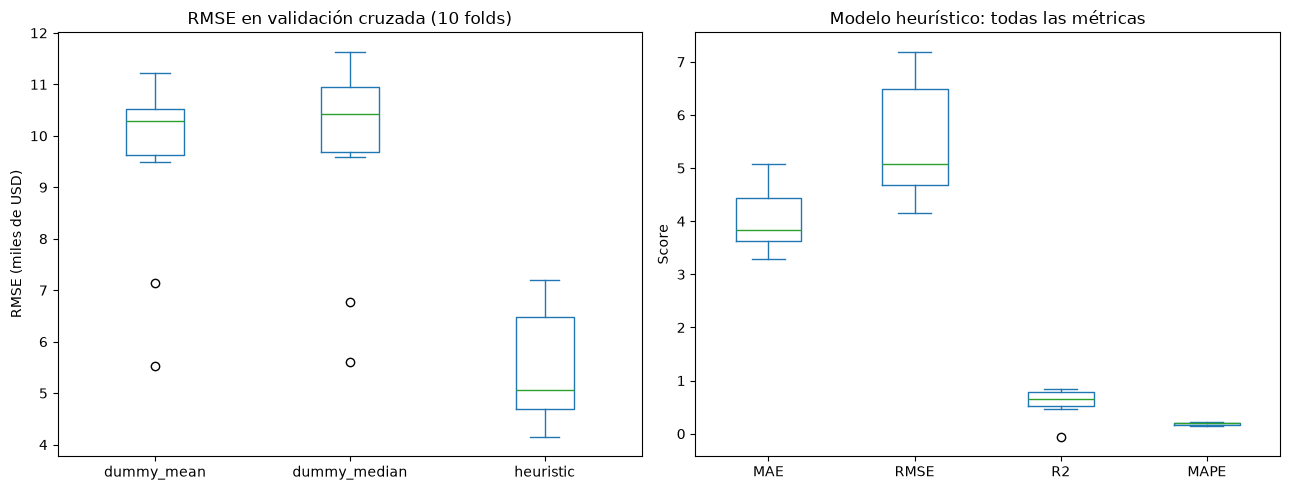

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

# comparación de los 3 modelos base en la métrica principal
cv_folds_df.xs(MAIN_METRIC, axis="columns", level=1).plot.box(
    ax=ax[0],
    title=f"{MAIN_METRIC} en validación cruzada ({N_SPLITS} folds)",
)
ax[0].set_ylabel(f"{MAIN_METRIC} (miles de USD)")

# todas las métricas del modelo heurístico
cv_folds_df["heuristic"].plot.box(
    ax=ax[1],
    title="Modelo heurístico: todas las métricas",
)
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

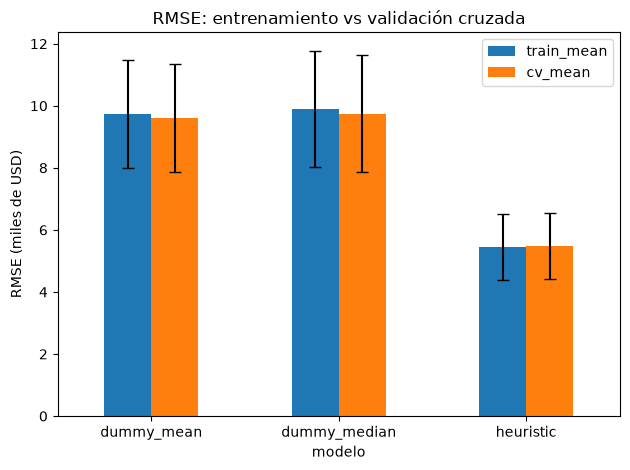

,train_mean,cv_mean,cv_std
modelo,,,
dummy_mean,9.74,9.60,1.74
dummy_median,9.89,9.74,1.88
heuristic,5.44,5.48,1.05


In [27]:
main_metric_summary = (
    cv_summary[cv_summary["metrica"] == MAIN_METRIC]
    .set_index("modelo")
    .loc[list(baseline_models)]
)

main_metric_summary.plot(
    kind="bar",
    y=["train_mean", "cv_mean"],
    yerr="cv_std",
    capsize=4,
    title=f"{MAIN_METRIC}: entrenamiento vs validación cruzada",
    ylabel=f"{MAIN_METRIC} (miles de USD)",
    rot=0,
)
plt.tight_layout()
plt.show()

main_metric_summary[["train_mean", "cv_mean", "cv_std"]]

In [28]:
selected_model_name = main_metric_summary["cv_mean"].idxmin()
dummy_reference = "dummy_mean"

improvement = (
    1
    - main_metric_summary.loc[selected_model_name, "cv_mean"]
    / main_metric_summary.loc[dummy_reference, "cv_mean"]
)

display(
    Markdown(
        f"""
**Modelo base seleccionado: `{selected_model_name}`** — es el que obtiene el menor
{MAIN_METRIC} en validación cruzada
({main_metric_summary.loc[selected_model_name, "cv_mean"]:.4f} ±
{main_metric_summary.loc[selected_model_name, "cv_std"]:.4f} miles de USD),
frente a {main_metric_summary.loc[dummy_reference, "cv_mean"]:.4f} del modelo dummy
de referencia: una reducción del error del **{improvement * 100:.1f} %**.
"""
    )
)


**Modelo base seleccionado: `heuristic`** — es el que obtiene el menor
RMSE en validación cruzada
(5.4837 ±
1.0528 miles de USD),
frente a 9.5966 del modelo dummy
de referencia: una reducción del error del **42.9 %**.


## 📊 Análisis de los resultados de la validación cruzada

**MAE (error absoluto medio)**
El dummy con la mediana obtiene mejor MAE (**6.97**) que el dummy con la media (**7.12**), lo que era esperable: la mediana es el estimador constante que minimiza el error absoluto, y la distribución de `medv` es asimétrica. El modelo heurístico baja el MAE a **3.99 ± 0.56**, un 44 % menos, porque asignar el precio típico del segmento en lugar de un único valor global ya captura buena parte de la variación de precios.

**RMSE (métrica principal)**
Entre los modelos constantes el mejor es el dummy con la media (**9.60 ± 1.74**), por definición la media minimiza el error cuadrático, y su valor coincide con la desviación estándar de `medv` en el entrenamiento (**9.74**). Ese número es el "costo de no tener modelo". El heurístico lo reduce a **5.48 ± 1.05** (−42.9 %) con solo dos variables y cuatro reglas.

**R²**
Los dos dummies quedan en R² ≈ 0 en entrenamiento (**0.0000** y **−0.0327**) y negativo en validación cruzada (**−0.04** y **−0.07**). Esto no es un error: en cada fold la constante se calcula con las filas de entrenamiento y se evalúa en filas distintas, por lo que nunca es óptima para el fold de validación. El heurístico alcanza **0.60**, es decir, explica una parte real de la varianza de `medv`, aunque con una desviación entre folds alta (**± 0.25**): el R² depende de la varianza propia de cada fold, y con folds de ~26 viviendas esa varianza cambia bastante de uno a otro.

**MAPE**
El heurístico obtiene **0.189**, menos de la mitad que los dummies (**0.386** y **0.350**). Es, en términos relativos, la métrica donde más mejora, pero también la que deja ver mejor el límite del modelo: un error relativo medio del **19 %** sigue siendo alto, y se concentra en las viviendas más baratas, donde el segmento `bajo` asigna un valor único de **11.65** mil USD mientras la vivienda más económica del dataset vale **5.0**. Los segmentos definidos con reglas son demasiado gruesos en el extremo inferior de precios.

**Entrenamiento vs validación cruzada (sobreajuste)**
Las diferencias entre el score de entrenamiento y el de validación cruzada son mínimas en los tres modelos (en el heurístico, RMSE **5.44** en train contra **5.48** en validación). Un modelo constante y un modelo de cuatro escalones tienen una capacidad muy limitada, así que **no hay sobreajuste; si algo hay, es subajuste (underfitting)**. La desviación estándar entre folds sí es apreciable, lo que refleja el tamaño reducido del conjunto de entrenamiento (256 filas): con folds de ~26 observaciones, unas pocas viviendas atípicas mueven bastante el promedio del fold.

# 📉 Análisis de Learning curve

La curva de aprendizaje muestra cómo cambia el error al aumentar la cantidad de datos de entrenamiento, y permite distinguir entre un problema de **sesgo** (el modelo es demasiado simple: ambas curvas se estabilizan en un error alto y muy cerca la una de la otra) y un problema de **varianza** (el modelo sobreajusta: el error de entrenamiento es bajo y el de validación mucho más alto).

Se calcula con `ShuffleSplit` de 50 particiones para tener estimaciones estables, usando RMSE como métrica. Se grafican los dos niveles de referencia (dummy y heurístico) para poder comparar la forma de las curvas, no solo su nivel — el ejemplo del profesor solo graficaba un modelo.

In [29]:
learning_curve_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=TEST_SIZE, random_state=123),
    "n_jobs": -1,
    "return_times": True,
    "scoring": "neg_root_mean_squared_error",
}

curves = {}
for name in ("dummy_mean", "heuristic"):
    sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
        baseline_models[name], **learning_curve_params
    )
    curves[name] = {
        "train_sizes": sizes,
        "train_mean": -train_scores.mean(axis=1),
        "train_std": train_scores.std(axis=1),
        "test_mean": -test_scores.mean(axis=1),
        "test_std": test_scores.std(axis=1),
        "fit_times_mean": fit_times.mean(axis=1),
        "fit_times_std": fit_times.std(axis=1),
        "score_times_mean": score_times.mean(axis=1),
        "score_times_std": score_times.std(axis=1),
    }

print("Tamaños de entrenamiento evaluados:", curves["heuristic"]["train_sizes"])

Tamaños de entrenamiento evaluados: [ 20  66 112 158 204]


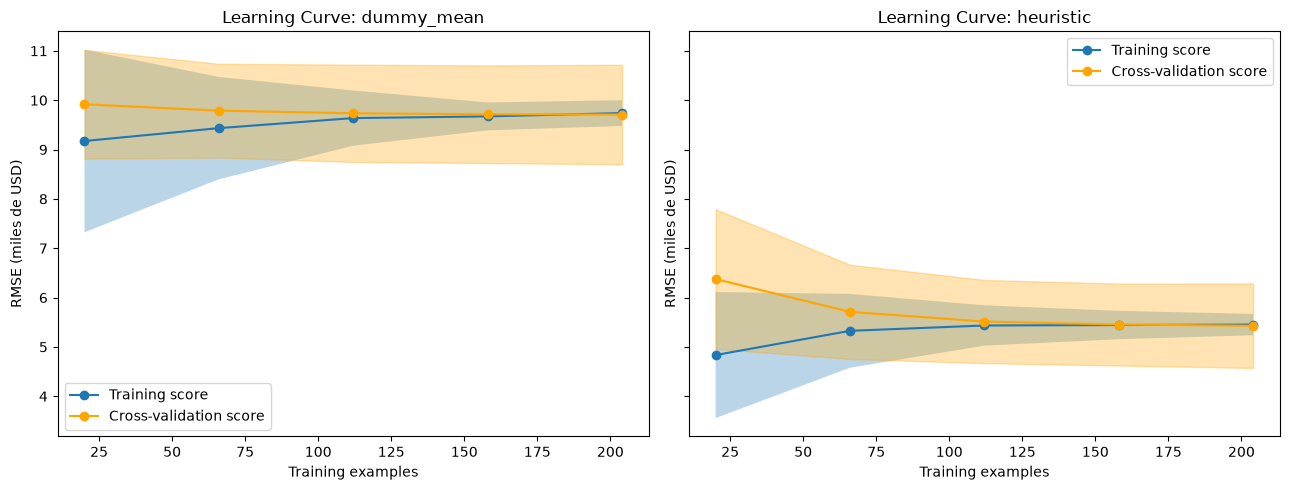

In [30]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5), sharey=True)

for ax, (name, curve) in zip(axes, curves.items(), strict=True):
    ax.plot(curve["train_sizes"], curve["train_mean"], "o-", label="Training score")
    ax.plot(
        curve["train_sizes"],
        curve["test_mean"],
        "o-",
        color="orange",
        label="Cross-validation score",
    )
    ax.fill_between(
        curve["train_sizes"],
        curve["train_mean"] - curve["train_std"],
        curve["train_mean"] + curve["train_std"],
        alpha=0.3,
    )
    ax.fill_between(
        curve["train_sizes"],
        curve["test_mean"] - curve["test_std"],
        curve["test_mean"] + curve["test_std"],
        alpha=0.3,
        color="orange",
    )
    ax.set_title(f"Learning Curve: {name}")
    ax.set_xlabel("Training examples")
    ax.set_ylabel(f"{MAIN_METRIC} (miles de USD)")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [31]:
for name, curve in curves.items():
    print(f"--- {name} ---")
    print("Training Sizes:", curve["train_sizes"])
    print("Training RMSE Mean:", np.round(curve["train_mean"], 4))
    print("Training RMSE Std :", np.round(curve["train_std"], 4))
    print("Test RMSE Mean:", np.round(curve["test_mean"], 4))
    print("Test RMSE Std :", np.round(curve["test_std"], 4))
    print()

--- dummy_mean ---
Training Sizes: [ 20  66 112 158 204]
Training RMSE Mean: [9.1727 9.4339 9.6372 9.6715 9.7388]
Training RMSE Std : [1.8494 1.0364 0.5589 0.2821 0.2612]
Test RMSE Mean: [9.9174 9.7877 9.7342 9.7153 9.7098]
Test RMSE Std : [1.1016 0.9502 0.9859 0.9897 1.0081]

--- heuristic ---
Training Sizes: [ 20  66 112 158 204]
Training RMSE Mean: [4.8354 5.3264 5.4344 5.4438 5.4527]
Training RMSE Std : [1.2771 0.7479 0.4082 0.2871 0.2162]
Test RMSE Mean: [6.3757 5.7106 5.5144 5.454  5.4301]
Test RMSE Std : [1.4152 0.9553 0.843  0.8306 0.856 ]



## Interpretación de la Learning curve (RMSE)

**Modelo dummy**
Las dos curvas son prácticamente planas y casi superpuestas: el error de validación pasa de **9.92** a **9.71** entre 20 y 204 observaciones de entrenamiento, es decir no baja al agregar datos porque el modelo no usa las variables predictoras. Es la firma visual de un modelo con sesgo máximo, y funciona como línea de referencia horizontal para leer la otra curva.

**Modelo heurístico**
Aquí sí se ve el patrón clásico: la curva de entrenamiento sube (**4.84 → 5.45**) y la de validación baja (**6.38 → 5.43**) hasta juntarse. Con el tamaño más pequeño (**20 observaciones**) la curva de validación es más inestable y su banda de desviación estándar más amplia (**± 1.42**), porque las medianas de cada segmento se calculan con muy pocas viviendas. A partir de unas **112 observaciones** ambas curvas dejan de moverse: el error de validación solo mejora de **5.51** a **5.43** al duplicar los datos.

**Conclusión del análisis**
La brecha entre entrenamiento y validación es prácticamente nula al final (**5.45** contra **5.43**): **no hay sobreajuste, hay subajuste**. Y como las curvas están planas, **agregar más datos del mismo tipo no mejoraría el desempeño del modelo base**: el límite no está en la cantidad de datos sino en la capacidad del modelo, que solo puede emitir cuatro valores distintos. La vía de mejora es aumentar la capacidad del modelo (usar más variables y un algoritmo que aprenda las fronteras en lugar de fijarlas a mano), no recolectar más observaciones. Esta es la conclusión más importante que aporta el modelo base para la siguiente etapa del proyecto.

# ⏱️ Escalabilidad: tiempos de entrenamiento y score

Tres gráficas complementarias sobre el modelo base seleccionado: cómo crece el tiempo de ajuste con el tamaño del conjunto de entrenamiento, cómo crece el tiempo de predicción, y qué desempeño se obtiene por unidad de tiempo invertido en entrenar. Esta última es la que permite comparar de forma honesta un modelo base con un modelo complejo: no basta con que el segundo tenga mejor score, tiene que compensar su costo.

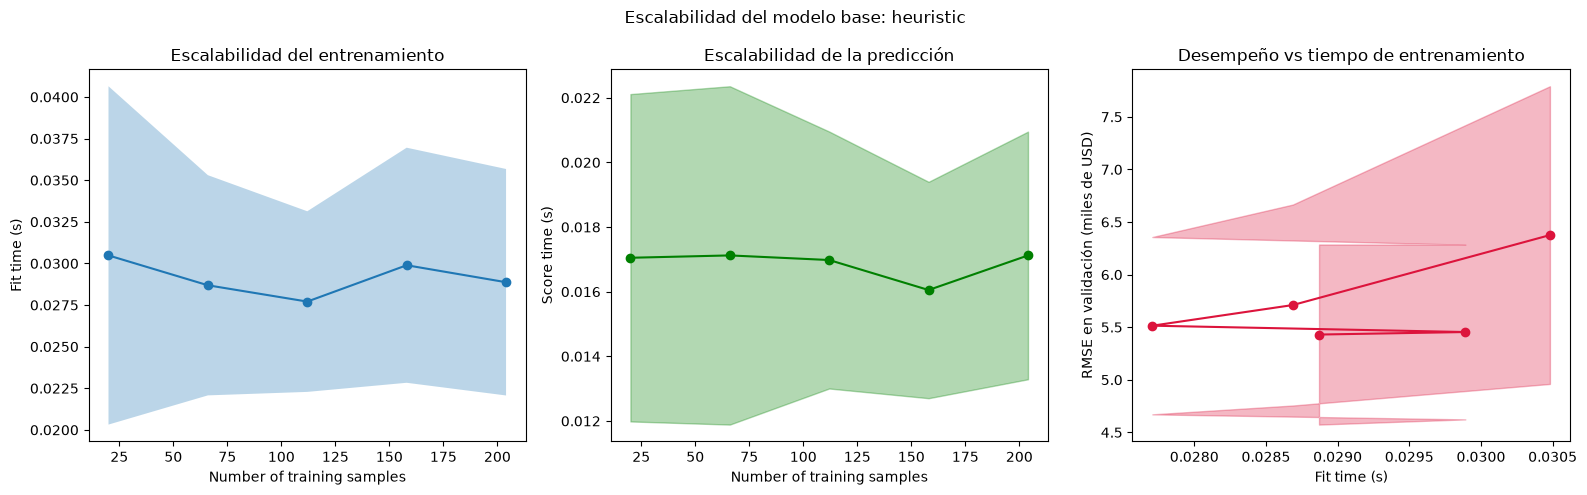

In [32]:
selected_curve = curves.get(selected_model_name, curves["heuristic"])

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

# 1. escalabilidad del tiempo de entrenamiento
ax[0].plot(selected_curve["train_sizes"], selected_curve["fit_times_mean"], "o-")
ax[0].fill_between(
    selected_curve["train_sizes"],
    selected_curve["fit_times_mean"] - selected_curve["fit_times_std"],
    selected_curve["fit_times_mean"] + selected_curve["fit_times_std"],
    alpha=0.3,
)
ax[0].set_xlabel("Number of training samples")
ax[0].set_ylabel("Fit time (s)")
ax[0].set_title("Escalabilidad del entrenamiento")

# 2. escalabilidad del tiempo de predicción
ax[1].plot(
    selected_curve["train_sizes"],
    selected_curve["score_times_mean"],
    "o-",
    color="green",
)
ax[1].fill_between(
    selected_curve["train_sizes"],
    selected_curve["score_times_mean"] - selected_curve["score_times_std"],
    selected_curve["score_times_mean"] + selected_curve["score_times_std"],
    alpha=0.3,
    color="green",
)
ax[1].set_xlabel("Number of training samples")
ax[1].set_ylabel("Score time (s)")
ax[1].set_title("Escalabilidad de la predicción")

# 3. desempeño obtenido por tiempo de entrenamiento invertido
ax[2].plot(
    selected_curve["fit_times_mean"],
    selected_curve["test_mean"],
    "o-",
    color="crimson",
)
ax[2].fill_between(
    selected_curve["fit_times_mean"],
    selected_curve["test_mean"] - selected_curve["test_std"],
    selected_curve["test_mean"] + selected_curve["test_std"],
    alpha=0.3,
    color="crimson",
)
ax[2].set_xlabel("Fit time (s)")
ax[2].set_ylabel(f"{MAIN_METRIC} en validación (miles de USD)")
ax[2].set_title("Desempeño vs tiempo de entrenamiento")

plt.suptitle(f"Escalabilidad del modelo base: {selected_model_name}")
plt.tight_layout()
plt.show()

In [33]:
print("Fit Times Mean:", np.round(selected_curve["fit_times_mean"], 6))
print("Fit Times Std :", np.round(selected_curve["fit_times_std"], 6))
print("Score Times Mean:", np.round(selected_curve["score_times_mean"], 6))
print("Score Times Std :", np.round(selected_curve["score_times_std"], 6))

print("\nTiempo medio de ajuste por modelo en la validación cruzada (s):")
print(cv_summary.groupby("modelo")["fit_time_mean"].mean().round(6))

Fit Times Mean: [0.030481 0.028687 0.027707 0.029891 0.02887 ]
Fit Times Std : [0.010162 0.006615 0.005425 0.007062 0.006803]
Score Times Mean: [0.01705  0.017122 0.01698  0.016052 0.017122]
Score Times Std : [0.005064 0.005234 0.003975 0.003347 0.003831]

Tiempo medio de ajuste por modelo en la validación cruzada (s):
modelo
dummy_mean     0.46
dummy_median   0.18
heuristic      0.03
Name: fit_time_mean, dtype: float64


## Interpretación de la escalabilidad

Los tiempos de ajuste y de predicción están en el orden de milisegundos y son esencialmente constantes: el `fit` se mantiene entre **0.028 y 0.030 s** y el `score` alrededor de **0.017 s** para tamaños de entrenamiento entre 20 y 204 filas. Tiene sentido, porque el `fit` del modelo heurístico solo calcula cuatro medianas y el `predict` es una asignación vectorizada, así que el costo real está en el preprocesamiento (imputación), que es lineal en el número de filas y a esta escala resulta imperceptible. La variabilidad entre repeticiones (las bandas sombreadas) llega a un tercio del valor medio (**± 0.005 a 0.010 s**), lo que indica que a esta escala se está midiendo sobre todo el ruido del sistema operativo y no el costo algorítmico.

Los tiempos medios de la tabla de validación cruzada (**0.46 s** para `dummy_mean`, **0.18 s** para `dummy_median` y **0.03 s** para el heurístico) no deben leerse como un costo algorítmico: `cross_validate` se ejecuta con `n_jobs=-1` y el primer modelo evaluado absorbe el arranque de los procesos paralelos. Los tres modelos tienen un costo de ajuste equivalente y despreciable.

La tercera gráfica es plana: invertir más tiempo de entrenamiento no mejora el RMSE de este modelo. En términos prácticos, el modelo base entrega su desempeño de forma esencialmente gratuita, así que cualquier modelo de machine learning que se proponga después debe justificar su costo adicional de cómputo con una mejora clara del error, y no marginal.

# 🧪 Evaluación final en el conjunto de prueba

El conjunto de prueba se usa una sola vez, al final, para estimar el desempeño del modelo base sobre datos que nunca intervinieron en ninguna decisión (ni en el preprocesamiento, ni en la selección de variables, ni en la elección del modelo).

In [34]:
test_records = []
predictions = {}

for name, pipe in baseline_models.items():
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    predictions[name] = y_pred

    test_records.append(
        {
            "modelo": name,
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        }
    )

test_results = pd.DataFrame(test_records).set_index("modelo")
test_results

,MAE,RMSE,R2,MAPE
modelo,,,,
dummy_mean,4.85,6.80,-0.05,0.27
dummy_median,4.82,6.66,-0.00,0.25
heuristic,3.00,4.02,0.63,0.15


In [35]:
# comparación entre validación cruzada (train) y conjunto de prueba
final_comparison = pd.DataFrame(
    {
        f"{MAIN_METRIC}_cv": main_metric_summary["cv_mean"],
        f"{MAIN_METRIC}_cv_std": main_metric_summary["cv_std"],
        f"{MAIN_METRIC}_test": test_results[MAIN_METRIC],
        "R2_test": test_results["R2"],
        "MAE_test": test_results["MAE"],
    }
)
final_comparison

,RMSE_cv,RMSE_cv_std,RMSE_test,R2_test,MAE_test
modelo,,,,,
dummy_mean,9.60,1.74,6.80,-0.05,4.85
dummy_median,9.74,1.88,6.66,-0.00,4.82
heuristic,5.48,1.05,4.02,0.63,3.00


### Predicciones vs valores reales y análisis de residuales

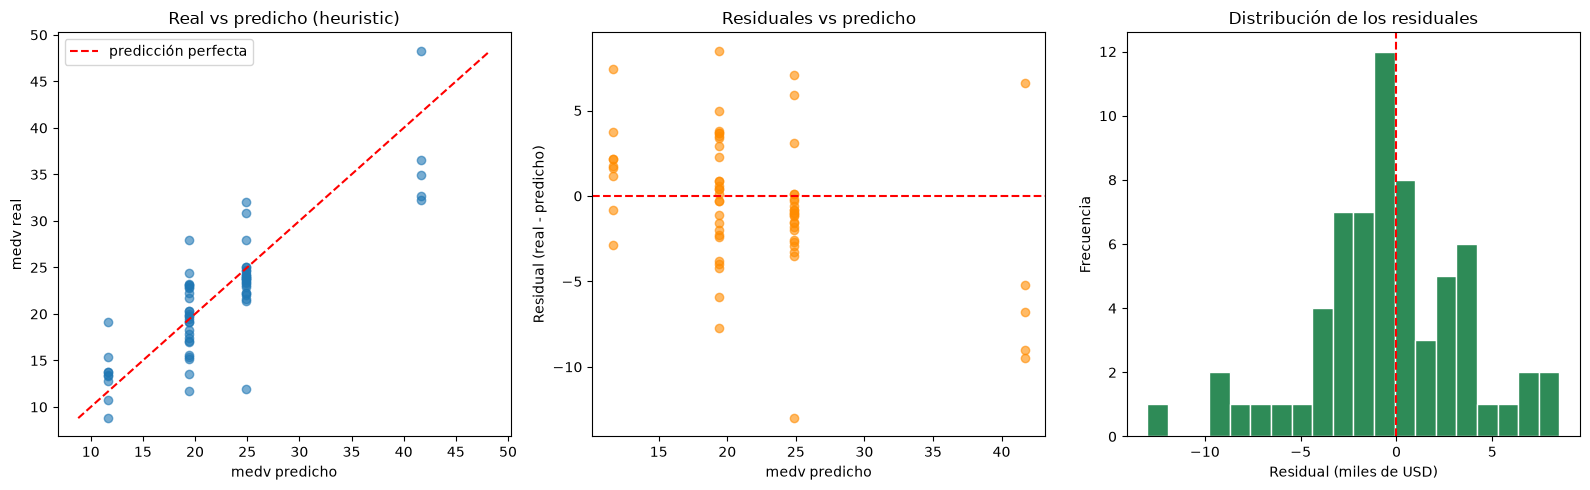

Residual medio (sesgo): -0.4408
Residual absoluto máximo: 13.0


In [36]:
y_pred_selected = predictions[selected_model_name]
residuals = y_test.to_numpy() - y_pred_selected

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

# 1. valores reales vs predichos
ax[0].scatter(y_pred_selected, y_test, alpha=0.6)
limits = [y_test.min(), y_test.max()]
ax[0].plot(limits, limits, "--", color="red", label="predicción perfecta")
ax[0].set_xlabel("medv predicho")
ax[0].set_ylabel("medv real")
ax[0].set_title(f"Real vs predicho ({selected_model_name})")
ax[0].legend()

# 2. residuales vs predicho
ax[1].scatter(y_pred_selected, residuals, alpha=0.6, color="darkorange")
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set_xlabel("medv predicho")
ax[1].set_ylabel("Residual (real - predicho)")
ax[1].set_title("Residuales vs predicho")

# 3. distribución de los residuales
ax[2].hist(residuals, bins=20, edgecolor="white", color="seagreen")
ax[2].axvline(0, color="red", linestyle="--")
ax[2].set_xlabel("Residual (miles de USD)")
ax[2].set_ylabel("Frecuencia")
ax[2].set_title("Distribución de los residuales")

plt.tight_layout()
plt.show()

print("Residual medio (sesgo):", round(residuals.mean(), 4))
print("Residual absoluto máximo:", round(np.abs(residuals).max(), 4))

In [37]:
# aporte de las observaciones censuradas (medv = 50) al error
residual_df = pd.DataFrame(
    {
        "medv_real": y_test,
        "medv_pred": y_pred_selected,
        "censurado": x_test["medv_censored"].to_numpy(),
    }
)
residual_df["residual"] = residual_df["medv_real"] - residual_df["medv_pred"]

error_by_group = residual_df.groupby("censurado")["residual"].agg(
    n="count",
    residual_medio="mean",
    mae=lambda values: values.abs().mean(),
    rmse=lambda values: np.sqrt((values**2).mean()),
)
error_by_group

,n,residual_medio,mae,rmse
censurado,,,,
0,65,-0.44,3.00,4.02


In [38]:
n_censored_test = int(residual_df["censurado"].sum())
dummy_row = test_results.loc[dummy_reference]
best_row = test_results.loc[selected_model_name]
rmse_gain = (1 - best_row["RMSE"] / dummy_row["RMSE"]) * 100

display(
    Markdown(
        f"""
**Resumen del modelo base en el conjunto de prueba ({len(y_test)} viviendas)**

| Métrica | {dummy_reference} | {selected_model_name} |
| --- | --- | --- |
| MAE (miles USD) | {dummy_row["MAE"]:.4f} | {best_row["MAE"]:.4f} |
| RMSE (miles USD) | {dummy_row["RMSE"]:.4f} | {best_row["RMSE"]:.4f} |
| R² | {dummy_row["R2"]:.4f} | {best_row["R2"]:.4f} |
| MAPE | {dummy_row["MAPE"]:.4f} | {best_row["MAPE"]:.4f} |

El modelo base seleccionado reduce el RMSE de prueba en **{rmse_gain:.1f} %**
respecto al dummy. En el conjunto de prueba hay {n_censored_test} observaciones
censuradas (`medv = 50`).
"""
    )
)


**Resumen del modelo base en el conjunto de prueba (65 viviendas)**

| Métrica | dummy_mean | heuristic |
| --- | --- | --- |
| MAE (miles USD) | 4.8530 | 2.9962 |
| RMSE (miles USD) | 6.8045 | 4.0208 |
| R² | -0.0454 | 0.6350 |
| MAPE | 0.2740 | 0.1505 |

El modelo base seleccionado reduce el RMSE de prueba en **40.9 %**
respecto al dummy. En el conjunto de prueba hay 0 observaciones
censuradas (`medv = 50`).


#### Interpretación de la evaluación final

**Coherencia entre validación cruzada y prueba.** Los tres modelos obtienen en prueba un RMSE **por debajo** del rango de su validación cruzada: el dummy pasa de **9.60 ± 1.74** a **6.80**, y el heurístico de **5.48 ± 1.05** a **4.02**. No es que el modelo funcione mejor de lo esperado, sino que **el conjunto de prueba resultó más fácil**: su desviación estándar de `medv` es ≈ **6.7** frente a ≈ **9.7** en entrenamiento, entre otras cosas porque las 11 viviendas censuradas en `medv = 50` quedaron todas en train. La prueba de que se trata del conjunto y no del modelo es que la caída es proporcional en ambos (−29 % y −27 %), y que el R² del dummy en prueba sigue siendo ≈ 0 (**−0.045**). Por eso **la referencia honesta para comparar los modelos de la siguiente tarea es el RMSE de validación cruzada (5.48), no el de prueba (4.02)**.

**Forma de las predicciones.** En la gráfica de real vs predicho las predicciones del modelo heurístico se agrupan en cuatro líneas verticales: solo existen cuatro valores posibles, uno por segmento. La diagonal roja muestra que el modelo acierta razonablemente en el rango medio de precios, pero **no alcanza los extremos**: subestima las viviendas más caras y sobrestima las más baratas. Este comportamiento —clásico de un modelo con sesgo alto— es visible también en la gráfica de residuales, donde estos siguen una tendencia descendente en lugar de estar repartidos al azar alrededor de cero.

**Residuales.** El residual medio es **−0.44** mil USD, es decir el modelo no está sesgado de forma apreciable en promedio, pero su dispersión es amplia: el error absoluto máximo es de **13.0** mil USD, más de tres veces el RMSE, y se produce en viviendas cuyo precio se aparta mucho del valor típico de su segmento. Un modelo de regresión bien especificado debería mostrar residuales sin patrón; que aquí sí haya patrón indica que queda información aprovechable en las variables que el modelo base no está usando.

**Observaciones censuradas.** La tabla de error por grupo tiene una sola fila (**65 viviendas, todas no censuradas**), porque las 11 observaciones con `medv = 50` quedaron en el conjunto de entrenamiento. El efecto de la censura no se puede medir aquí, pero sí se manifiesta en la validación cruzada: esas viviendas caen en el segmento `premium`, al que el modelo asigna **41.70**, de modo que aportan un error cercano a **8** mil USD cada una y explican parte de la desviación entre folds. Queda como tarea explícita para la siguiente entrega estratificar la partición por `medv_censored` o evaluar con y sin ese grupo.

# 💾 Guardar el modelo base y sus métricas

Se guardan el pipeline completo (preprocesamiento + modelo) y sus métricas en disco. Esto es lo que convierte al baseline en una referencia utilizable: en la siguiente tarea basta con cargar `baseline_metrics.json` para comparar cualquier modelo nuevo contra estos números, sin tener que volver a ejecutar este notebook. El ejemplo del profesor no incluía este paso.

In [39]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

baseline_path = MODELS_DIR / "baseline_model.joblib"
joblib.dump(baseline_models[selected_model_name], baseline_path)

cv_selected = (
    cv_summary[cv_summary["modelo"] == selected_model_name]
    .set_index("metrica")[["cv_mean", "cv_std", "train_mean"]]
    .astype(float)
    .to_dict(orient="index")
)


def to_native(mapping):
    # convierte los valores de numpy a tipos nativos para poder serializar
    return {key: float(value) for key, value in mapping.items()}


metrics_payload = {
    "model": selected_model_name,
    "model_type": "heuristic_rules" if "heuristic" in selected_model_name else "dummy",
    "main_metric": MAIN_METRIC,
    "n_train": int(len(x_train)),
    "n_test": int(len(x_test)),
    "most_important_feature": str(best_feature),
    "cross_validation": {
        metric: to_native(values) for metric, values in cv_selected.items()
    },
    "test": to_native(test_results.loc[selected_model_name].to_dict()),
    "dummy_reference_test": to_native(test_results.loc[dummy_reference].to_dict()),
    "sklearn_version": sk.__version__,
    "random_state": RANDOM_STATE,
}

metrics_path = MODEL_OUTPUT_DIR / "baseline_metrics.json"
with metrics_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics_payload, metrics_file, indent=2, ensure_ascii=False)

print("Modelo guardado en:", baseline_path)
print("Métricas guardadas en:", metrics_path)
print(json.dumps(metrics_payload, indent=2, ensure_ascii=False))

Modelo guardado en: /home/maricel98/Precios-casas-Boston/data/06_models/baseline_model.joblib
Métricas guardadas en: /home/maricel98/Precios-casas-Boston/data/07_model_output/baseline_metrics.json
{
  "model": "heuristic",
  "model_type": "heuristic_rules",
  "main_metric": "RMSE",
  "n_train": 256,
  "n_test": 65,
  "most_important_feature": "lstat",
  "cross_validation": {
    "MAE": {
      "cv_mean": 3.991992307692307,
      "cv_std": 0.5634046234841471,
      "train_mean": 3.861593826463392
    },
    "RMSE": {
      "cv_mean": 5.4837474656823915,
      "cv_std": 1.0527847147916194,
      "train_mean": 5.443424774316642
    },
    "R2": {
      "cv_mean": 0.5999839883969367,
      "cv_std": 0.25172673795489275,
      "train_mean": 0.687078827676117
    },
    "MAPE": {
      "cv_mean": 0.18909595129221,
      "cv_std": 0.02124257748210525,
      "train_mean": 0.18460084932531656
    }
  },
  "test": {
    "MAE": 2.9961538461538457,
    "RMSE": 4.020796897669378,
    "R2": 0.634995

# 📊 Análisis e interpretación de los resultados

**Qué se logró medir.** El proyecto ya tiene una referencia cuantitativa: el error que se comete sin modelo (dummy) y el error que se consigue con reglas de negocio sobre las dos variables más informativas (heurístico). Cualquier modelo de machine learning que se entrene en la siguiente tarea deberá compararse contra estos dos números en la misma partición de datos, con la misma semilla y el mismo pipeline, para que la comparación sea válida.

**El dummy define el piso.** Su RMSE equivale a la desviación estándar de `medv` y su R² es ≈ 0 por construcción (ligeramente negativo en validación cruzada, porque la constante se calcula en cada fold con datos distintos a los de evaluación). Interpretado en términos del negocio: sin modelo, la mejor apuesta posible es "el precio típico del mercado", y el error asociado a esa apuesta es la referencia que hay que batir.

**El heurístico demuestra que hay señal aprovechable.** Con solo dos variables (`lstat` y `rm`) y cuatro reglas fijas se reduce el error de forma sustancial respecto al dummy y se obtiene un R² claramente positivo. Esto valida dos cosas: que los hallazgos de los EDA eran correctos (las variables señaladas efectivamente contienen información sobre el precio) y que el pipeline de datos del notebook 06 funciona de extremo a extremo dentro de la validación cruzada. En cifras: RMSE de validación cruzada de **5.48 ± 1.05** contra **9.60 ± 1.74** del dummy (−42.9 %), y R² de **0.60** contra **−0.04**.

- **Extremos de la distribución**: subestima las viviendas caras y sobrestima las más baratas, donde el MAPE se degrada (el segmento `bajo` predice **11.65** mil USD frente a precios reales de hasta **5.0**). El caso extremo son las 11 viviendas censuradas en `medv = 50`, que el modelo predice en **41.70**; al haber quedado todas en entrenamiento, su efecto aparece en la validación cruzada y no en la evaluación final.

**Diagnóstico técnico.** La combinación de una brecha pequeña entre entrenamiento y validación, curvas de aprendizaje planas y residuales con patrón apunta a un caso de **sesgo alto / varianza baja (subajuste)**. Es exactamente lo que se espera —y se desea— de un modelo base: es estable, rápido y honesto, y deja margen de mejora evidente.

# 📈 Conclusiones

**El modelo base cumple su función de referencia.** Quedan documentados dos niveles comparables y reproducibles: el piso absoluto (dummy) y una referencia razonable con conocimiento del dominio (heurístico). Ambos con la misma partición, la misma semilla, el mismo pipeline y las métricas guardadas en disco.

**El modelo heurístico supera claramente al dummy**, lo que confirma que las variables seleccionadas en los EDA tienen valor predictivo real y que vale la pena entrenar modelos de machine learning sobre este dataset.

**No hay sobreajuste, hay subajuste.** Los scores de entrenamiento y validación cruzada son muy parecidos y las curvas de aprendizaje son planas. El límite del modelo base es su capacidad, no la cantidad de datos.

**Más datos del mismo tipo no ayudarían.** La curva de aprendizaje se estabiliza alrededor de las **112 observaciones**: duplicar los datos desde ahí solo mejora el RMSE de validación de **5.51** a **5.43**. Con 256 filas ya se agotó lo que este modelo puede extraer; el esfuerzo debe ir a modelos con mayor capacidad y a mejores atributos, no a recolectar más observaciones.

**El costo computacional del baseline es despreciable** (milisegundos, sin crecimiento apreciable con el tamaño de los datos), así que constituye una referencia exigente en la relación desempeño/costo: un modelo complejo tiene que ganar en error de forma significativa para justificarse.

**La censura en `medv = 50` sigue siendo un problema abierto.** Las 11 observaciones afectadas quedaron todas en el conjunto de entrenamiento, así que no distorsionan la evaluación final pero sí la validación cruzada: el modelo les asigna **41.70** mil USD, con un error cercano a 8 mil USD por vivienda. La partición de la siguiente tarea debería estratificarse por `medv_censored` para poder medir su efecto de forma explícita.

**La variable más importante es `lstat`**, seleccionada de forma consistente por cuatro criterios distintos (Pearson, Spearman, información mutua y R² univariado), con `rm` como segunda variable complementaria.

# 🧑‍🔬 Recomendaciones para construir el siguiente modelo

**Usar el pipeline completo, no solo dos variables.**
Recomendación: entrenar los modelos de machine learning con el `preprocessor` completo (24 columnas) que ya está validado en este notebook.
Justificación: el modelo base deja doce columnas sin usar y su análisis de residuales muestra que queda estructura sin explicar.

**Empezar por una regresión lineal regularizada y luego árboles.**
Recomendación: `Ridge`/`Lasso` como primer modelo interpretable, y después `RandomForestRegressor` y `HistGradientBoostingRegressor`.
Justificación: la relación de `lstat` con `medv` no es lineal (el análisis bivariable mostró curvatura), así que los modelos basados en árboles deberían superar a los lineales; la lineal sirve para tener un punto intermedio interpretable entre el heurístico y los modelos complejos.

**Mantener RMSE como métrica de decisión y reportar MAE al lado.**
Recomendación: seguir usando el mismo diccionario `scoring_metrics` y la misma `KFold` con `shuffle=True` y `random_state=42`.
Justificación: solo las comparaciones hechas con el mismo protocolo son válidas; cambiar la partición o la métrica invalida la comparación contra este baseline.

**Definir el criterio de aceptación antes de entrenar.**
Recomendación: exigir que el modelo nuevo mejore el RMSE del heurístico en al menos una desviación estándar de la validación cruzada.
Justificación: sin ese umbral, cualquier mejora decimal puede confundirse con una mejora real cuando en realidad está dentro del ruido entre folds.

**Tratar explícitamente las observaciones censuradas.**
Recomendación: evaluar el modelo con y sin las 11 filas de `medv = 50`, usando la columna `medv_censored` que ya viene del notebook 06.
Justificación: en esta partición quedaron las 11 en entrenamiento, así que su efecto contamina la validación cruzada sin poder verificarse en prueba; además son las que producen los errores más grandes y pueden sesgar el ajuste de un modelo que minimiza el error cuadrático.

**Extraer el preprocesamiento a un módulo de `src/`.**
Recomendación: mover la preparación de datos y la definición del `preprocessor` a funciones reutilizables e importarlas en los notebooks.
Justificación: hoy esa lógica está duplicada entre el notebook 06 y este; cualquier cambio debe hacerse en dos lugares, lo que es una fuente de errores silenciosos y complica los checks de CI/CD.

**Registrar cada experimento contra el baseline.**
Recomendación: guardar métricas de cada modelo en `data/07_model_output/` con el mismo formato de `baseline_metrics.json` (o usar MLflow si el curso lo permite).
Justificación: permite construir una tabla comparativa acumulada en lugar de recordar resultados de ejecuciones anteriores.

**Estratificar la partición también por `medv_censored`.**
Recomendación: pasar a `train_test_split` una estratificación combinada de `chas` y `medv_censored`, dejando documentado que cambia la partición respecto a este notebook.
Justificación: con la división actual el conjunto de prueba es notablemente menos disperso que el de entrenamiento (desviación estándar de `medv` ≈ 6.7 contra ≈ 9.7), lo que hace que todos los modelos parezcan mejores en prueba que en validación cruzada y complica la lectura de los resultados.

# 💡 Propuestas e ideas

**Heurística de segundo nivel como referencia intermedia.**
Propuesta: aumentar los segmentos del modelo heurístico (por ejemplo, cruzar cuartiles de `lstat` con cuartiles de `rm`, o usar un árbol de decisión de profundidad 2 o 3).
Razón: acortaría la distancia entre el baseline y los modelos complejos, y daría una referencia más exigente conservando la interpretabilidad. Un árbol de profundidad limitada es, en esencia, una heurística que aprende sus propios umbrales.

**Modelar el término de interacción `rm` × `lstat`.**
Propuesta: incluir `PolynomialFeatures(interaction_only=True)` en el pipeline de los modelos lineales.
Razón: tanto el análisis multivariable como el diseño del segmento `premium` de este notebook sugieren que el efecto de `rm` depende del nivel de `lstat`; los modelos lineales no lo capturan por sí solos.

**Transformar la variable objetivo.**
Propuesta: entrenar sobre `log(medv)` (o usar `TransformedTargetRegressor`) y comparar el RMSE devuelto a la escala original.
Razón: `medv` es asimétrica a la derecha; trabajar en escala logarítmica suele estabilizar la varianza de los errores y reducir el efecto de las viviendas más caras.

**Tratar la censura como un problema aparte.**
Propuesta: probar un clasificador binario que detecte "vivienda en el techo de precio" y un regresor para el resto, o usar un modelo de regresión censurada (Tobit).
Razón: mezclar dos procesos generadores distintos en un solo regresor es lo que produce los errores grandes del segmento `premium` en la validación cruzada, donde el modelo asigna 41.70 a viviendas cuyo precio está topado en 50.

**Optimizar hiperparámetros con validación cruzada anidada.**
Propuesta: usar `GridSearchCV`/`RandomizedSearchCV` dentro del pipeline, con la búsqueda encapsulada para que la selección de hiperparámetros no vea los datos de validación.
Razón: ajustar hiperparámetros mirando el mismo conjunto con el que se compara contra el baseline produce estimaciones optimistas.

**Analizar la importancia de variables por permutación.**
Propuesta: aplicar `permutation_importance` al mejor modelo y comparar el ranking con el de este notebook.
Razón: el ranking univariado de aquí ignora las interacciones y la redundancia entre variables; la importancia por permutación mide el aporte de cada variable dentro del modelo ya entrenado.

**Cuantificar la incertidumbre de las predicciones.**
Propuesta: añadir intervalos de predicción (por ejemplo con `GradientBoostingRegressor` en modo cuantil o mediante bootstrap).
Razón: en una valoración de vivienda, un rango de precios es más útil para decidir que un único número, y hace explícita la incertidumbre que el modelo base no comunica.

# ➕ Adiciones respecto al ejemplo del profesor

El ejemplo de referencia resuelve un problema de clasificación (Titanic) con un modelo heurístico. Además de adaptar todo a un problema de regresión, en este notebook se agregaron o corrigieron los siguientes puntos:

1. **Modelo dummy además del heurístico.** La Issue 5 menciona explícitamente `sklearn.dummy`; el ejemplo del profesor no lo usa. Aquí se incluyen dos estrategias de `DummyRegressor` como piso formal de comparación.
2. **`random_state` fijo en el `train_test_split`.** En el ejemplo la partición cambia en cada ejecución, por lo que sus resultados no son reproducibles (de hecho, los números de su texto de análisis no coinciden con los de sus propias celdas).
3. **`KFold` con `shuffle=True`.** Sin mezclar, los folds del dataset de Boston quedan agrupados por zona geográfica y la desviación estándar entre folds mide el orden del archivo, no la variabilidad del modelo.
4. **Score de entrenamiento correcto por métrica.** El ejemplo usa `model_pipe.score(...)`, que en un clasificador siempre devuelve accuracy: por eso su "Train score" es idéntico para accuracy, F1, precision y recall. Aquí se usa `cross_validate(..., return_train_score=True)`, que devuelve el valor de la métrica correspondiente.
5. **Una sola pasada de validación cruzada para todas las métricas** con `cross_validate`, en lugar de un `cross_val_score` por métrica (que además reentrenaba el modelo dentro del bucle).
6. **Selección de la variable más importante con cuatro criterios** (Pearson, Spearman, información mutua y R² univariado) calculados solo sobre el conjunto de entrenamiento, en lugar de justificarla únicamente de forma narrativa.
7. **Predicción vectorizada** en el modelo heurístico con `np.select`, en lugar de un bucle de Python fila por fila; y validación explícita de la forma de la entrada.
8. **Valores de segmento estimados en `fit()`** (medianas del entrenamiento) en lugar de constantes escritas a mano, evitando que el modelo dependa de números arbitrarios.
9. **Curvas de aprendizaje de dos modelos en la misma escala**, para comparar la forma de las curvas y no solo su nivel.
10. **Tercera gráfica de escalabilidad** (score frente a tiempo de ajuste), que es la que permite evaluar la relación desempeño/costo frente a modelos más complejos.
11. **Análisis de residuales** (real vs predicho, residuales vs predicho, distribución) y **medición del error en el subgrupo censurado**, ausentes en el ejemplo.
12. **Verificación de fuga de datos** entre train y test, y confirmación de que el preprocesamiento se ajusta solo con datos de entrenamiento.
13. **Persistencia del modelo y de las métricas** (`joblib` + JSON) para que el baseline sea realmente reutilizable como referencia en la siguiente tarea.
14. **Criterio de aceptación explícito** para el próximo modelo (superar el RMSE del baseline en al menos una desviación estándar de la validación cruzada).

# 🔀 Flujo de trabajo con Git (Gitflow)

Comandos usados para desarrollar y entregar esta tarea:

```bash
# 1. crear la rama de la tarea a partir de main actualizado
git checkout main
git pull origin main
git checkout -b feature/05-baseline-model

# 2. trabajar y confirmar los cambios
git add notebooks/*/07.baseline_model-mkmh-2026-08-28.ipynb
git commit -m "feat: modelo base con DummyRegressor y modelo heuristico (Issue 5)"

# 3. subir la rama al repositorio remoto
git push -u origin feature/05-baseline-model

# 4. crear el Pull Request hacia main desde GitHub y solicitar
#    al menos 1 revisión de otra persona del curso.
#    El PR solo se puede fusionar cuando pasen los checks de CI/CD.
```

# 📖 References

- Ejemplo de modelo base (dataset Titanic) — Jose R. Zapata, profesor del curso.
- https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/
- https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/
- https://joserzapata.github.io/post/lista-proyecto-machine-learning/
- https://scikit-learn.org/stable/api/sklearn.dummy.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/learning_curve.html
- https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 2nd Edition — Aurélien Géron.